In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
filename = '/home/lacrio/Downloads/transfer_13662390_files_314b8ad0/T2_snowfox_lf.dat'

df = pd.read_csv(filename, skiprows=[0, 2,3])
df.columns

Index(['TIMESTAMP', 'RECORD', 'Batt_Min', 'PTemp_Avg', 'Tair_1_Avg',
       'Tair_2_Avg', 'Hum_1_Avg', 'Hum_2_Avg', 'SWin_Avg', 'SWout_Avg',
       'LWin_Avg', 'LWout_Avg', 'CNR4TC_Avg', 'LWinCor_Avg', 'LWoutCor_Avg',
       'Wspeed', 'Wdir', 'Wspeed_Max', 'DT_raw', 'Q', 'TCDT', 'Snow_Depth',
       'Press_Avg'],
      dtype='object')

In [24]:
vars_sel = ['TIMESTAMP', 'Tair_2_Avg', 'Hum_2_Avg', 'SWin_Avg', 'SWout_Avg', 'LWinCor_Avg', 'LWoutCor_Avg',
            'Wspeed', 'Wdir', 'Snow_Depth', 'Press_Avg']

df_sel = df[vars_sel]
# Parse datetime and adjust offset (+3 hours)
df_sel["TIMESTAMP"] = pd.to_datetime(df_sel["TIMESTAMP"]) 
df_sel = df_sel.set_index("TIMESTAMP")

df_sel = df_sel.loc['2023-08-18':'2023-08-24']

/tmp/ipykernel_18216/1528630223.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sel["TIMESTAMP"] = pd.to_datetime(df_sel["TIMESTAMP"])


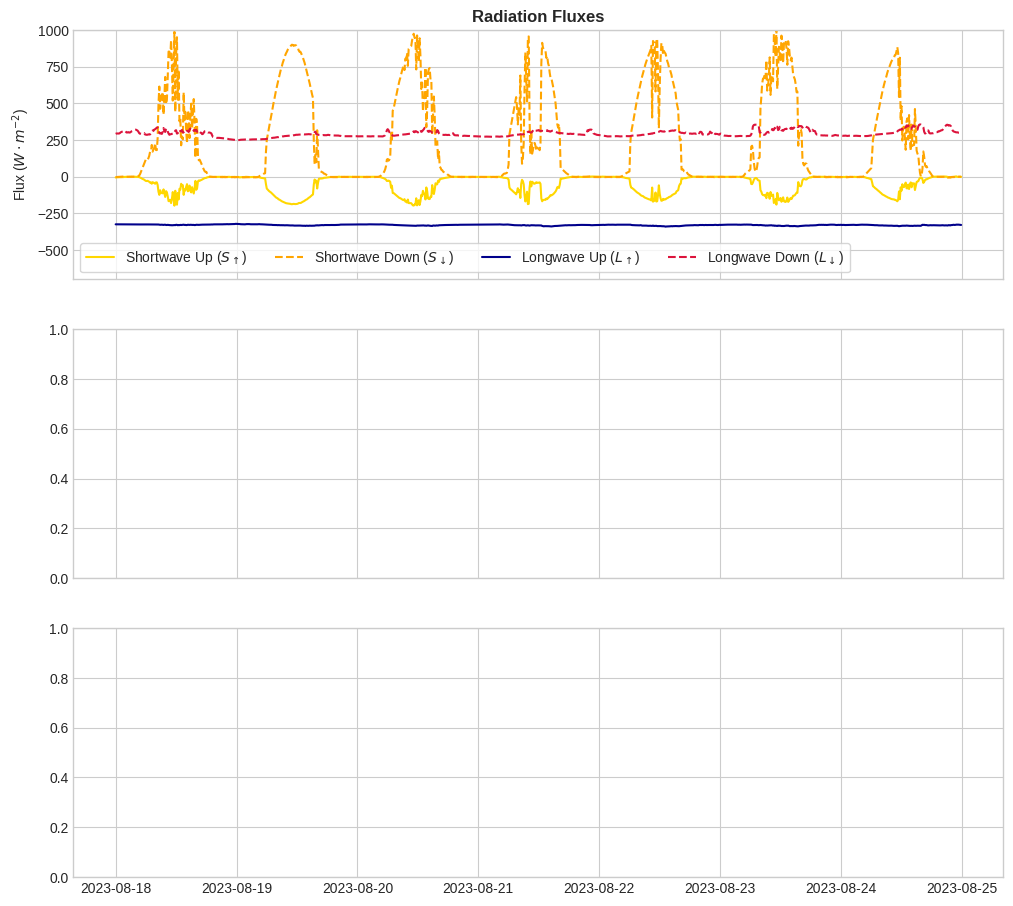

In [25]:
# 2. Figure Setup with 3 Subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)

# --- Subplot 1: Radiation Fluxes ---
# Intercambiamos los labels entre SDn y SUp, y entre LDnCo y LUpCo para ajustar a los datos reales
ax1.plot(
    df_sel.index,
    -df_sel["SWout_Avg"],
    label="Shortwave Up ($S_{\\uparrow}$)",
    color="gold",
    linewidth=1.5,
)
ax1.plot(
    df_sel.index,
    df_sel["SWin_Avg"],
    label="Shortwave Down ($S_{\\downarrow}$)",
    color="orange",
    linestyle="--",
    linewidth=1.5,
)
ax1.plot(
    df_sel.index,
    -df_sel["LWoutCor_Avg"],
    label="Longwave Up ($L_{\\uparrow}$)",
    color="darkblue",
    linewidth=1.5,
)
ax1.plot(
    df_sel.index,
    df_sel["LWinCor_Avg"],
    label="Longwave Down ($L_{\\downarrow}$)",
    color="crimson",
    linestyle="--",
    linewidth=1.5,
)
ax1.set_ylabel("Flux ($W\\cdot m^{-2}$)", fontsize=10)
ax1.set_title("Radiation Fluxes", fontsize=12, fontweight="bold")
ax1.set_ylim(-700, 1000)
ax1.legend(loc="lower left", frameon=True, ncol=4)
